# SHAP Analysis — Diabetes Risk Decision Support System

This notebook covers **Key Driver Analysis** using SHAP (SHapley Additive exPlanations) for:

1. **Risk Classification** — Random Forest (best model): global importance, beeswarm per class, single-patient waterfall
2. **Lifestyle Segmentation** — K-Means (proxy RF approach): cluster feature drivers

All reusable functions live in `src/SHAP_analysis.py` and are imported here.

## 0. Setup

In [1]:
import sys
import pickle
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

warnings.filterwarnings('ignore')

# ── Resolve project root so imports work regardless of where the notebook is opened ──
NOTEBOOK_DIR = Path().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent  # MLG382-GUIDED-PROJECT/
SRC_DIR      = PROJECT_ROOT / 'src'
DATA_DIR     = PROJECT_ROOT / 'data'
ARTIFACTS    = PROJECT_ROOT / 'artifacts'

sys.path.insert(0, str(SRC_DIR))
from SHAP_analysis import (
    load_model,
    get_tree_explainer,
    compute_shap_values,
    plot_global_importance,
    plot_beeswarm,
    plot_waterfall,
    get_cluster_explainer,
    plot_cluster_importance,
    build_cluster_profiles,
)

# ── Class names (must match label encoder order) ──
CLASS_NAMES = ['Gestational', 'No Diabetes', 'Pre-Diabetes', 'Type 1', 'Type 2']
CLUSTER_NAMES = ['Cluster 0 — Low Risk', 'Cluster 1 — Moderate Risk', 'Cluster 2 — High Risk']

print('Project root :', PROJECT_ROOT)
print('Artifacts dir:', ARTIFACTS)
shap.initjs()

c:\Projects\MLG382-Guided-Project-main\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Project root : C:\Projects\MLG382-Guided-Project-main
Artifacts dir: C:\Projects\MLG382-Guided-Project-main\artifacts


## 1. Load Data & Models

In [2]:
# ── Processed feature sets ──
X_train        = pd.read_csv(DATA_DIR / 'X_train.csv')
X_test         = pd.read_csv(DATA_DIR / 'X_test.csv')
y_test         = pd.read_csv(DATA_DIR / 'y_test.csv').squeeze('columns')
X_train_scaled = pd.read_csv(DATA_DIR / 'X_train_scaled.csv')
X_test_scaled  = pd.read_csv(DATA_DIR / 'X_test_scaled.csv')

print(f'X_test shape        : {X_test.shape}')
print(f'X_test_scaled shape : {X_test_scaled.shape}')
print(f'Features            : {list(X_test.columns)}')

X_test shape        : (19460, 28)
X_test_scaled shape : (19460, 28)
Features            : ['Age', 'alcohol_consumption_per_week', 'physical_activity_minutes_per_week', 'diet_score', 'sleep_hours_per_day', 'screen_time_hours_per_day', 'bmi', 'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate', 'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol', 'triglycerides', 'glucose_fasting', 'glucose_postprandial', 'insulin_level', 'hba1c', 'family_history_diabetes', 'hypertension_history', 'cardiovascular_history', 'education_level', 'income_level', 'gender', 'ethnicity', 'employment_status', 'smoking_status']


In [3]:
# ── Load trained models ──
rf_model     = load_model('random_forest.pkl')
kmeans_model = load_model('kmeans.pkl')

print('Random Forest loaded :', rf_model)
print('KMeans loaded        :', kmeans_model)

Random Forest loaded : RandomForestClassifier(class_weight='balanced', max_depth=20,
                       min_samples_split=10, n_estimators=400, n_jobs=-1,
                       random_state=42)
KMeans loaded        : KMeans(n_clusters=3, n_init=20, random_state=42)


## 2. SHAP for Risk Classification (Random Forest)

We use a **250-row stratified sample** of the test set to keep computation fast while staying representative.

In [4]:
# ── Stratified sample ──
SAMPLE_SIZE = 250

sample_idx = (
    pd.DataFrame({'idx': X_test.index, 'label': y_test.values})
    .groupby('label', group_keys=False)
    .apply(lambda g: g.sample(min(len(g), SAMPLE_SIZE // len(CLASS_NAMES)), random_state=42))
    ['idx'].values
)

X_sample = X_test.loc[sample_idx].reset_index(drop=True)
y_sample = y_test.loc[sample_idx].reset_index(drop=True)

print(f'Sample size: {len(X_sample)}')
print('Class distribution in sample:')
print(y_sample.value_counts().sort_index())

Sample size: 223
Class distribution in sample:
diabetes_stage
0    50
1    50
2    50
3    23
4    50
Name: count, dtype: int64


In [5]:
# ── Build TreeExplainer & compute SHAP values ──
rf_explainer = get_tree_explainer(rf_model)
raw_shap = compute_shap_values(rf_explainer, X_sample)

# Normalise to always be a list of 2D arrays (one per class)
# Some SHAP versions return a 3D array (samples, features, classes) instead
if isinstance(raw_shap, np.ndarray) and raw_shap.ndim == 3:
    shap_values = [raw_shap[:, :, i] for i in range(raw_shap.shape[2])]
    print("Converted 3D array → list of 2D arrays")
elif isinstance(raw_shap, list):
    shap_values = raw_shap
    print("SHAP returned list format directly")
else:
    raise ValueError(f"Unexpected SHAP output type: {type(raw_shap)}, shape: {np.array(raw_shap).shape}")

print(f'Number of class arrays : {len(shap_values)}')
print(f'Shape per class array  : {shap_values[0].shape}  (samples × features)')
print(f'X_sample shape         : {X_sample.shape}')

assert shap_values[0].shape[0] == X_sample.shape[0], "Sample count mismatch!"
assert shap_values[0].shape[1] == X_sample.shape[1], "Feature count mismatch!"
print("Shape check passed ✓")

SHAP returned list format directly
Number of class arrays : 5
Shape per class array  : (223, 28)  (samples × features)
X_sample shape         : (223, 28)
Shape check passed ✓


### 2.1 Global Feature Importance — All Classes

Mean absolute SHAP values across all five diabetes stage classes.

Saved: C:\Projects\MLG382-Guided-Project-main\artifacts\shap_global_importance.png


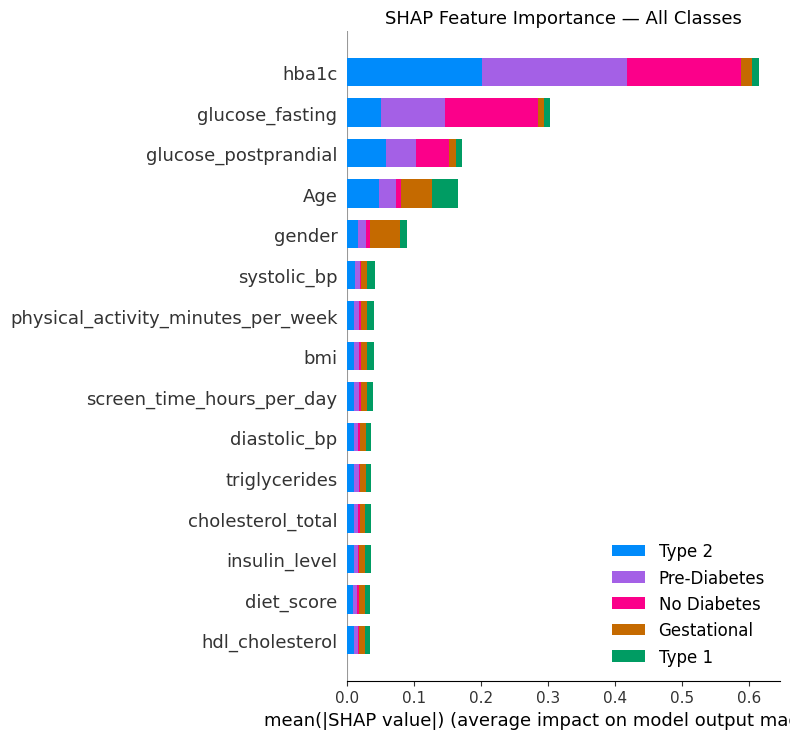

In [6]:
plot_global_importance(
    shap_values,
    X_sample,
    class_names=CLASS_NAMES,
    save_path=ARTIFACTS / 'shap_global_importance.png',
    max_display=15
)

### 2.2 Beeswarm Plots — Direction of Impact per Class

Each dot is one patient. Color = feature value (red = high, blue = low). Horizontal position = SHAP impact on that class probability.

Saved: C:\Projects\MLG382-Guided-Project-main\artifacts\shap_beeswarm_gestational.png


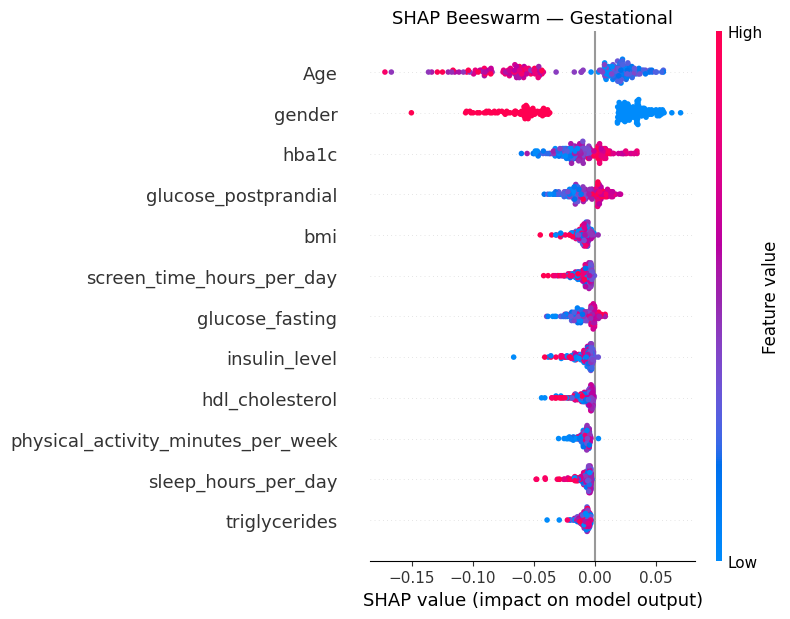

Saved: C:\Projects\MLG382-Guided-Project-main\artifacts\shap_beeswarm_no_diabetes.png


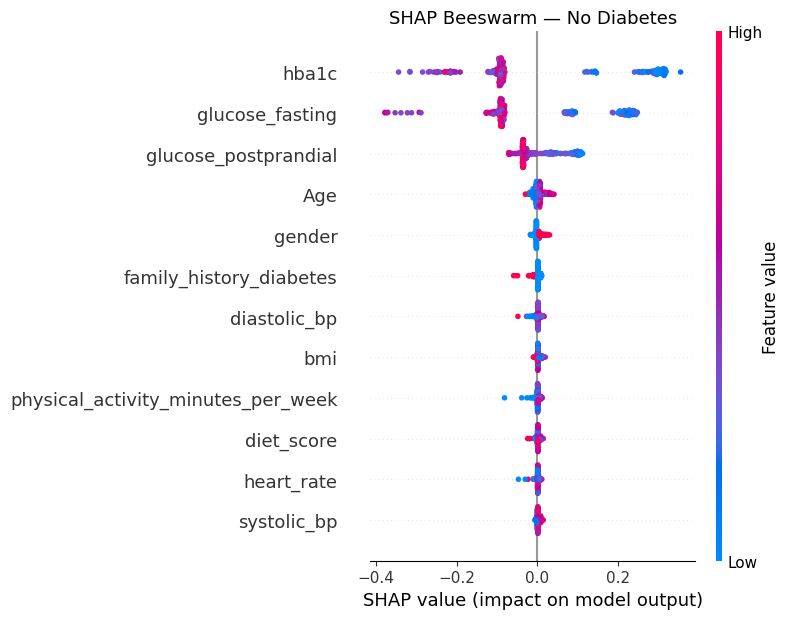

Saved: C:\Projects\MLG382-Guided-Project-main\artifacts\shap_beeswarm_pre-diabetes.png


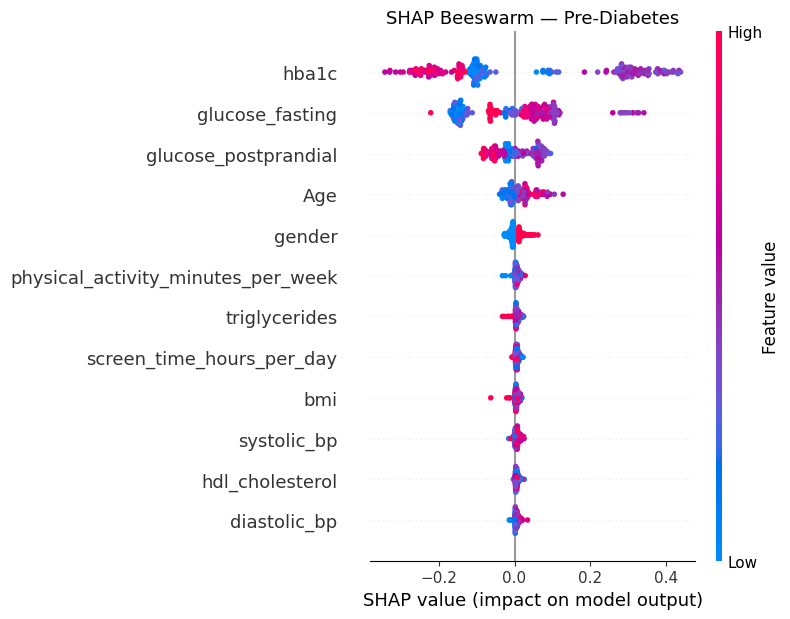

Saved: C:\Projects\MLG382-Guided-Project-main\artifacts\shap_beeswarm_type_1.png


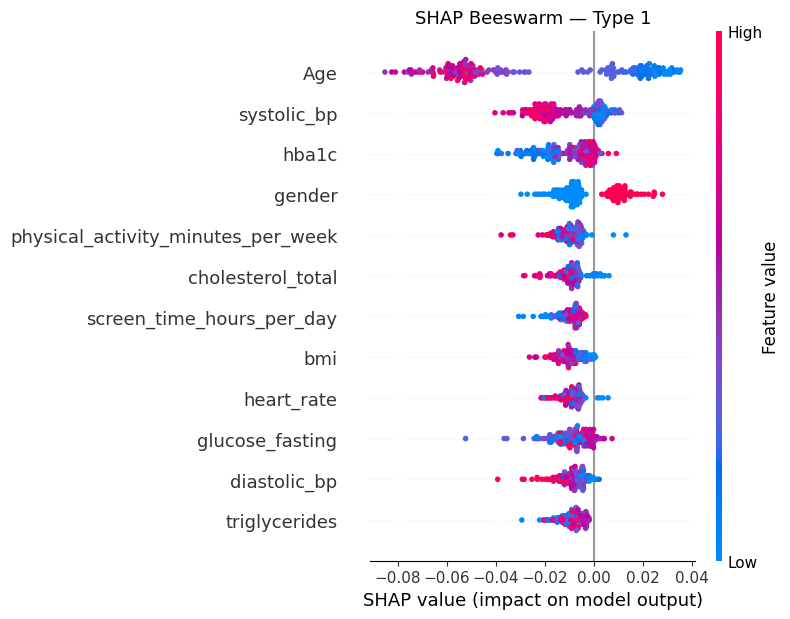

Saved: C:\Projects\MLG382-Guided-Project-main\artifacts\shap_beeswarm_type_2.png


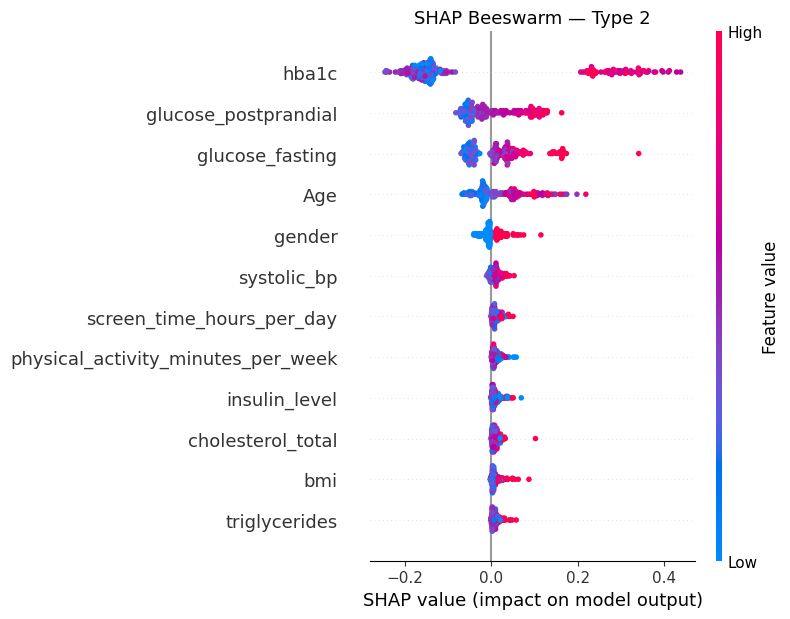

In [7]:
for class_idx, class_name in enumerate(CLASS_NAMES):
    save_name = f"shap_beeswarm_{class_name.lower().replace(' ', '_')}.png"
    plot_beeswarm(
        shap_values_class=shap_values[class_idx],
        X_sample=X_sample,
        class_name=class_name,
        save_path=ARTIFACTS / save_name,
        max_display=12
    )

### 2.3 Waterfall Plot — Single Patient Explanation

Explains **why** the model predicted a specific class for one patient. The base value (E[f(x)]) is the average model output; each bar shows how much a feature pushed the prediction up or down.


Patient 0 | True: Gestational | Predicted: No Diabetes


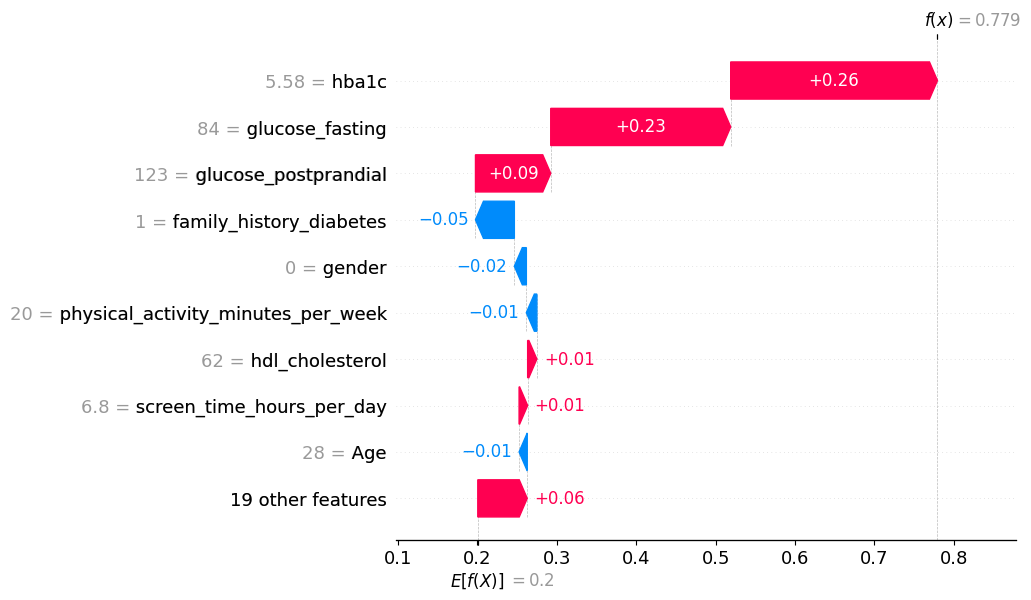

Saved: C:\Projects\MLG382-Guided-Project-main\artifacts\shap_waterfall_gestational.png


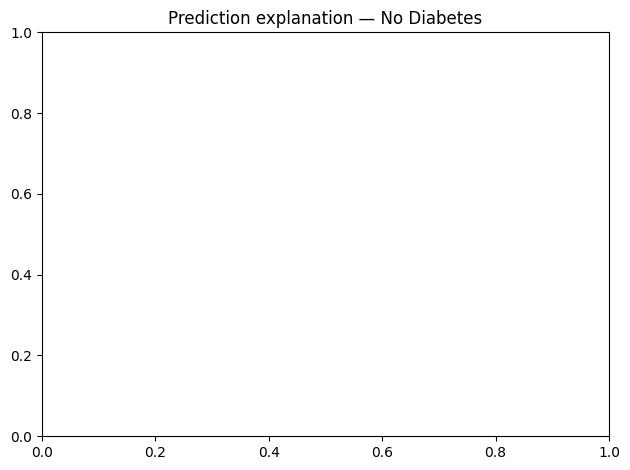


Patient 50 | True: No Diabetes | Predicted: No Diabetes


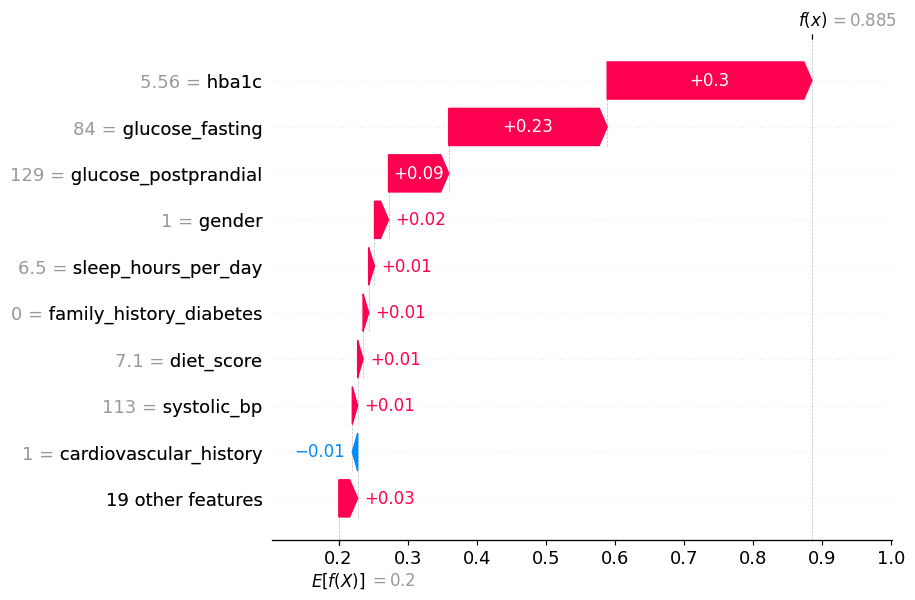

Saved: C:\Projects\MLG382-Guided-Project-main\artifacts\shap_waterfall_no_diabetes.png


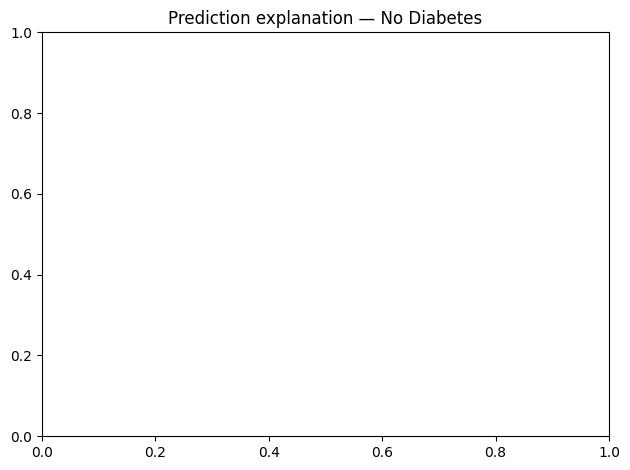


Patient 100 | True: Pre-Diabetes | Predicted: Pre-Diabetes


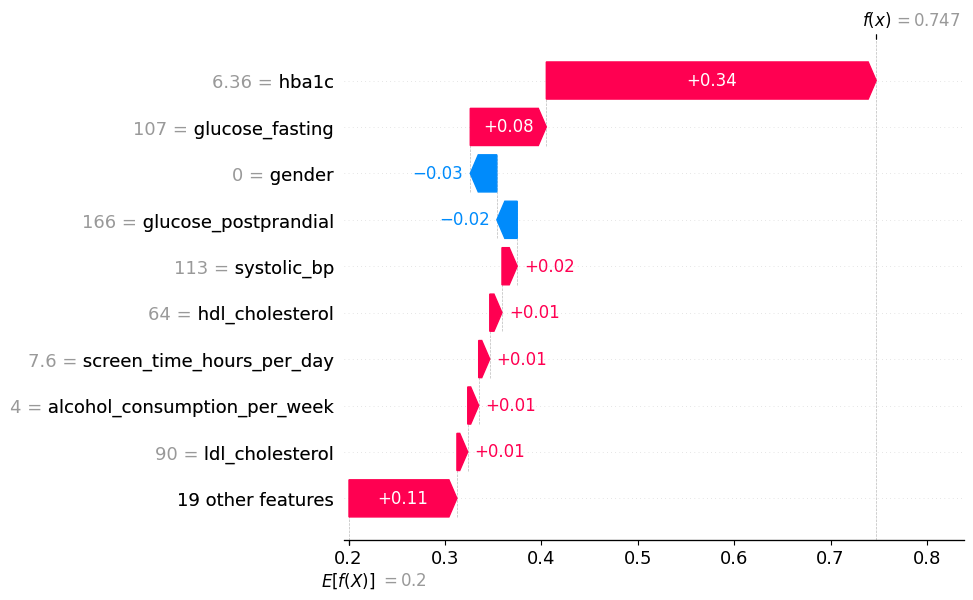

Saved: C:\Projects\MLG382-Guided-Project-main\artifacts\shap_waterfall_pre-diabetes.png


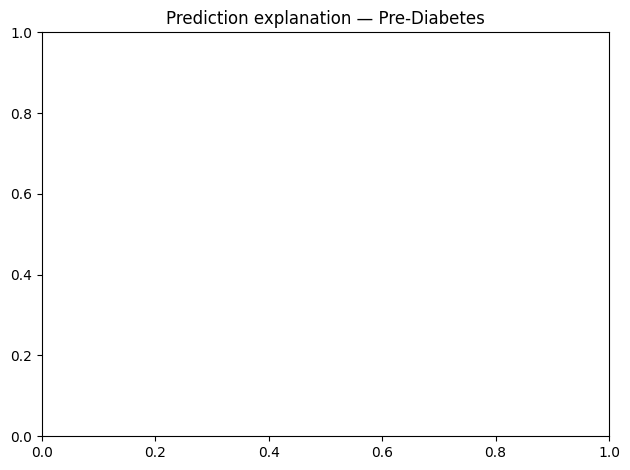


Patient 150 | True: Type 1 | Predicted: Pre-Diabetes


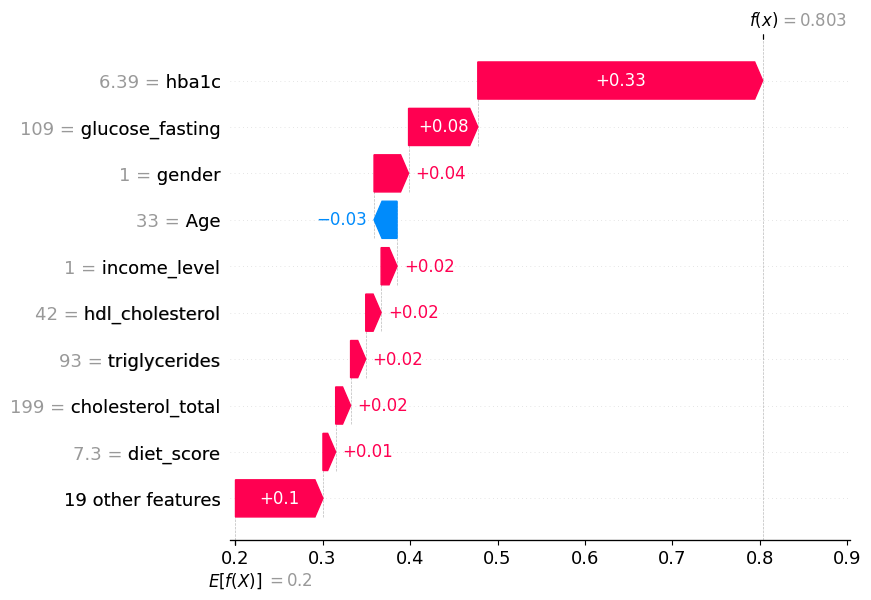

Saved: C:\Projects\MLG382-Guided-Project-main\artifacts\shap_waterfall_type_1.png


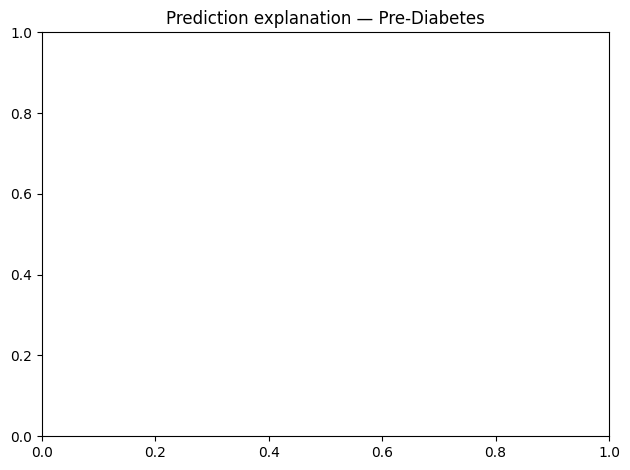


Patient 173 | True: Type 2 | Predicted: Type 2


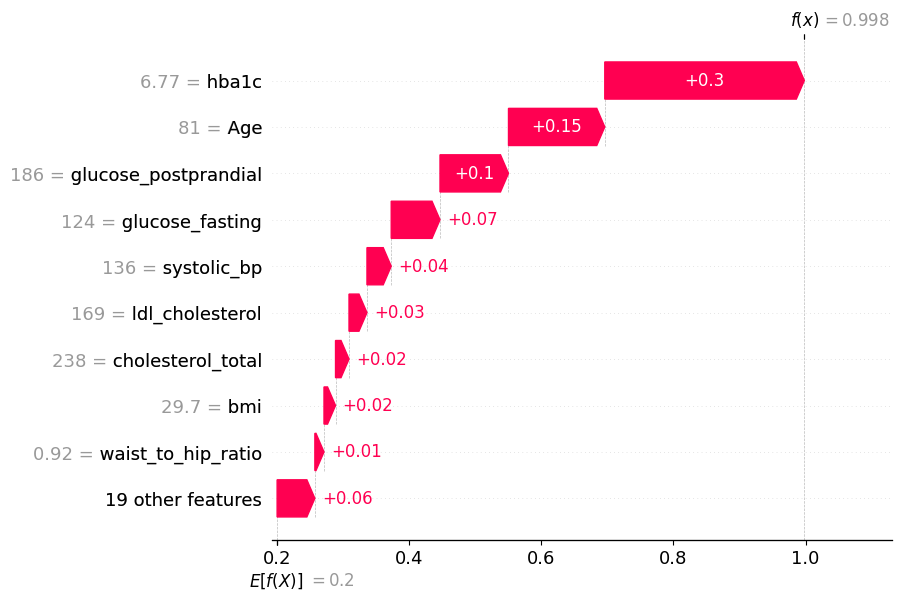

Saved: C:\Projects\MLG382-Guided-Project-main\artifacts\shap_waterfall_type_2.png


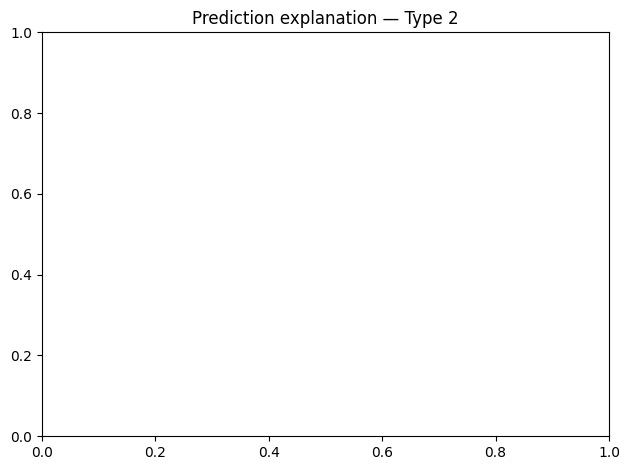

In [8]:
# ── Pick one patient from each class for a thorough demonstration ──
for target_class_idx, class_name in enumerate(CLASS_NAMES):
    # Find first patient in the sample whose true label matches this class
    class_patients = y_sample[y_sample == target_class_idx].index.tolist()
    if not class_patients:
        print(f'No sample patients found for class {class_name}, skipping.')
        continue

    patient_index = class_patients[0]
    predicted_class_idx = int(rf_model.predict(X_sample.iloc[[patient_index]])[0])
    predicted_name = CLASS_NAMES[predicted_class_idx]
    true_name      = CLASS_NAMES[target_class_idx]

    print(f'\nPatient {patient_index} | True: {true_name} | Predicted: {predicted_name}')

    save_name = f"shap_waterfall_{class_name.lower().replace(' ', '_')}.png"
    plot_waterfall(
        explainer=rf_explainer,
        shap_values=shap_values,
        X_sample=X_sample,
        patient_index=patient_index,
        predicted_class_idx=predicted_class_idx,
        class_names=CLASS_NAMES,
        save_path=ARTIFACTS / save_name
    )

### 2.4 SHAP Summary Table — Top 10 Drivers per Class

A tabular view of mean |SHAP| per feature per class, useful for the technical report.

In [9]:
summary_rows = {}
for class_idx, class_name in enumerate(CLASS_NAMES):
    mean_abs_shap = np.abs(shap_values[class_idx]).mean(axis=0)
    summary_rows[class_name] = mean_abs_shap

shap_summary_df = pd.DataFrame(summary_rows, index=X_sample.columns)
shap_summary_df['Overall Mean |SHAP|'] = shap_summary_df.mean(axis=1)
shap_summary_df = shap_summary_df.sort_values('Overall Mean |SHAP|', ascending=False)

print('=== Top 10 features by mean |SHAP| (across all classes) ===')
display(shap_summary_df.head(10).style.background_gradient(cmap='YlOrRd', axis=0).format('{:.4f}'))

shap_summary_df.to_csv(ARTIFACTS / 'shap_feature_summary.csv')
print('\nSaved → artifacts/shap_feature_summary.csv')

=== Top 10 features by mean |SHAP| (across all classes) ===


,Gestational,No Diabetes,Pre-Diabetes,Type 1,Type 2,Overall Mean |SHAP|
hba1c,0.0174,0.1687,0.2171,0.0108,0.2011,0.1230
glucose_fasting,0.0091,0.1387,0.0943,0.0088,0.0510,0.0604
glucose_postprandial,0.0118,0.0486,0.0453,0.0080,0.0572,0.0342
Age,0.0453,0.0078,0.0260,0.0387,0.0468,0.0329
gender,0.0447,0.0060,0.0122,0.0107,0.0159,0.0179
systolic_bp,0.0081,0.0026,0.0067,0.0127,0.0116,0.0083
physical_activity_minutes_per_week,0.0083,0.0034,0.0073,0.0101,0.0106,0.0079
bmi,0.0095,0.0035,0.0069,0.0094,0.0101,0.0079
screen_time_hours_per_day,0.0092,0.0025,0.0070,0.0095,0.0107,0.0078
diastolic_bp,0.0078,0.0039,0.0063,0.0087,0.0094,0.0072



Saved → artifacts/shap_feature_summary.csv


## 3. SHAP for Lifestyle Segmentation (K-Means)

K-Means has no native SHAP support. We train a **proxy Random Forest** to predict cluster labels from the scaled features, then apply `TreeExplainer` to it. This reveals which lifestyle features define each cluster.

In [ ]:
# ── Sample X_test_scaled to keep SHAP computation fast (mirrors section 2) ──
CLUSTER_SAMPLE_SIZE = 500
X_test_scaled_sample = X_test_scaled.sample(n=CLUSTER_SAMPLE_SIZE, random_state=42).reset_index(drop=True)
print(f'Cluster SHAP sample size: {len(X_test_scaled_sample)}')

# Force reimport so fixes to SHAP_analysis.py are picked up without restarting kernel
import importlib, SHAP_analysis
importlib.reload(SHAP_analysis)
from SHAP_analysis import get_cluster_explainer, plot_cluster_importance

# ── Build proxy RF explainer for K-Means ──
cluster_explainer, cluster_shap_values, rf_proxy = get_cluster_explainer(
    kmeans_model=kmeans_model,
    X_train_scaled=X_train_scaled,
    X_test_scaled=X_test_scaled_sample
)

print(f'Proxy RF trained. Cluster SHAP arrays: {len(cluster_shap_values)}')
for i, sv in enumerate(cluster_shap_values):
    print(f'  cluster_shap_values[{i}] shape: {sv.shape}')

### 3.1 Cluster Feature Importance — Bar Chart

In [ ]:
plot_cluster_importance(
    shap_values_cluster=cluster_shap_values,
    X_test_scaled=X_test_scaled_sample,
    cluster_names=CLUSTER_NAMES,
    save_path=ARTIFACTS / 'shap_cluster_importance.png',
    max_display=15
)

### 3.2 Cluster Beeswarm — Direction of Lifestyle Impact per Cluster

In [ ]:
n_features = X_test_scaled_sample.shape[1]

for cluster_idx, cluster_name in enumerate(CLUSTER_NAMES):
    sv = cluster_shap_values[cluster_idx]
    # Some SHAP versions append a bias/offset column — strip it if present
    if sv.shape[1] > n_features:
        sv = sv[:, :n_features]

    plt.figure(figsize=(10, 7))
    shap.summary_plot(
        sv,
        X_test_scaled_sample,
        show=False,
        max_display=12
    )
    plt.title(f'SHAP Beeswarm — {cluster_name}', fontsize=13)
    plt.tight_layout()

    save_name = f"shap_cluster_beeswarm_{cluster_idx}.png"
    plt.savefig(ARTIFACTS / save_name, dpi=150, bbox_inches='tight')
    print(f'Saved: {save_name}')
    plt.show()

### 3.3 Cluster Profile Table

Mean scaled feature values per cluster — a human-readable description of each lifestyle group.

In [ ]:
profile = build_cluster_profiles(
    kmeans_model=kmeans_model,
    X_train_scaled=X_train_scaled,
    save_path=ARTIFACTS / 'cluster_profiles.csv'
)

print('=== Cluster Mean Feature Profiles (scaled) ===')
display(
    profile.style
    .background_gradient(cmap='RdYlGn', axis=1)
    .format('{:.3f}')
)

### 3.4 Cluster Heatmap

Visual comparison of all clusters across every feature.

In [ ]:
import seaborn as sns

profile.columns = CLUSTER_NAMES

fig, ax = plt.subplots(figsize=(8, max(6, len(profile) * 0.45)))
sns.heatmap(
    profile,
    annot=True, fmt='.2f',
    cmap='RdYlGn',
    linewidths=0.5,
    ax=ax
)
ax.set_title('Cluster Profiles — Mean Scaled Feature Values', fontsize=13)
ax.set_xlabel('Cluster')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.savefig(ARTIFACTS / 'shap_cluster_heatmap.png', dpi=150, bbox_inches='tight')
print('Saved: shap_cluster_heatmap.png')
plt.show()

## 4. Key Findings Summary

This cell prints a concise interpretation of the SHAP results for each section of the technical report.

In [ ]:
top10 = shap_summary_df.head(10).index.tolist()

print('=' * 60)
print('SHAP KEY FINDINGS')
print('=' * 60)
print()
print('── Risk Classification (Random Forest) ──')
print(f'Top 10 global drivers: {", ".join(top10)}')
print()

for class_idx, class_name in enumerate(CLASS_NAMES):
    top3 = shap_summary_df[class_name].nlargest(3).index.tolist()
    print(f'  {class_name:<18} top drivers: {", ".join(top3)}')

print()
print('── Lifestyle Segmentation (K-Means via Proxy RF) ──')
for cluster_idx in range(3):
    mean_abs = np.abs(cluster_shap_values[cluster_idx]).mean(axis=0)
    top3_cluster = pd.Series(mean_abs, index=X_test_scaled.columns).nlargest(3).index.tolist()
    print(f'  {CLUSTER_NAMES[cluster_idx]:<35} top drivers: {", ".join(top3_cluster)}')

print()
print('Artifacts saved to:', ARTIFACTS)